In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# eliminam formatul stiintific pentru probabilitati
np.set_printoptions(suppress=True)

# incarcam datele
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# eliminam atributele stress_level, anxiety_level si addiction_level
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

# transformam variabile text in numerice
def encode_text(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

categoriale = ['gender', 'platform_usage', 'social_interaction_level']
df = encode_text(df, categoriale)

# separare X (atribute) si y (scop)
X = df.drop('depression_label', axis=1).values.astype(np.float32)
y = df['depression_label'].values.astype(np.float32)

# standardizam datele
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# functie pentru rularea experimentului KNN
def experiment_knn(k_fold_val, n_vecini, p_param, alg_val, nume_exp):
    print(f"\n\n--- {nume_exp} ---")
    print(f"Parametri: Vecini={n_vecini}, p={p_param} (Minkowski), Algoritm={alg_val}")
    
    # construirea modelului KNN
    # p=2 inseamna distanta Euclidiana, p=1 inseamna distanta Manhattan
    knn = KNeighborsClassifier(n_neighbors=n_vecini, p=p_param, algorithm=alg_val, metric='minkowski')
    kf = KFold(n_splits=k_fold_val, shuffle=True, random_state=42)
    
    # predictiile modelului prin k-fold 
    y_pred = cross_val_predict(knn, X_std, y, cv=kf)
    
    # calcularea probabilitatilor 
    y_proba = cross_val_predict(knn, X_std, y, cv=kf, method='predict_proba')

    # afisarea claselor si a probabilitatilor pentru primele instante
    knn.fit(X_std, y)
    print('\nClasele:', knn.classes_)
    print('Probabilitatile ptr. primele 5 instante test (%):\n', y_proba[:5] * 100)

    # numararea instantelor clasificate gresit 
    print("\nInstante clasificate gresit dintr-un total de %d inregistrari : %d" % (len(y), (y != y_pred).sum()))

    # acuratetea de clasificare 
    print("Acuratetea de clasificare = % 5.2f" % accuracy_score(y, y_pred))
    
    # afisare raport de clasificare complet
    print("\nRaportul de clasificare:")
    print(classification_report(y, y_pred))
    
    # matricea de confuzie numeric
    cm = confusion_matrix(y, y_pred)
    print('Matricea de confuzie:\n', cm)
    
    # reprezentare grafica
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # matricea de confuzie grafica
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
    disp.plot(ax=ax[0], cmap='YlOrBr')
    ax[0].set_title(f"Matrice Confuzie {nume_exp}")
    
    # comparare valori reale vs predictii (esantion 50 instante)
    t = pd.DataFrame({'real': y[:50], 'predit': y_pred[:50]})
    ax[1].plot(t['real'].tolist(), label='Real', marker='o', linestyle='')
    ax[1].plot(t['predit'].tolist(), label='Predit', marker='x', linestyle='')
    ax[1].set_title("Real vs Predictie KNN")
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()



--- Exp_KNN_1 ---
Parametri: Vecini=5, p=2 (Minkowski), Algoritm=auto

Clasele: [0. 1.]
Probabilitatile ptr. primele 5 instante test (%):
 [[100.   0.]
 [100.   0.]
 [100.   0.]
 [100.   0.]
 [ 80.  20.]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 31
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


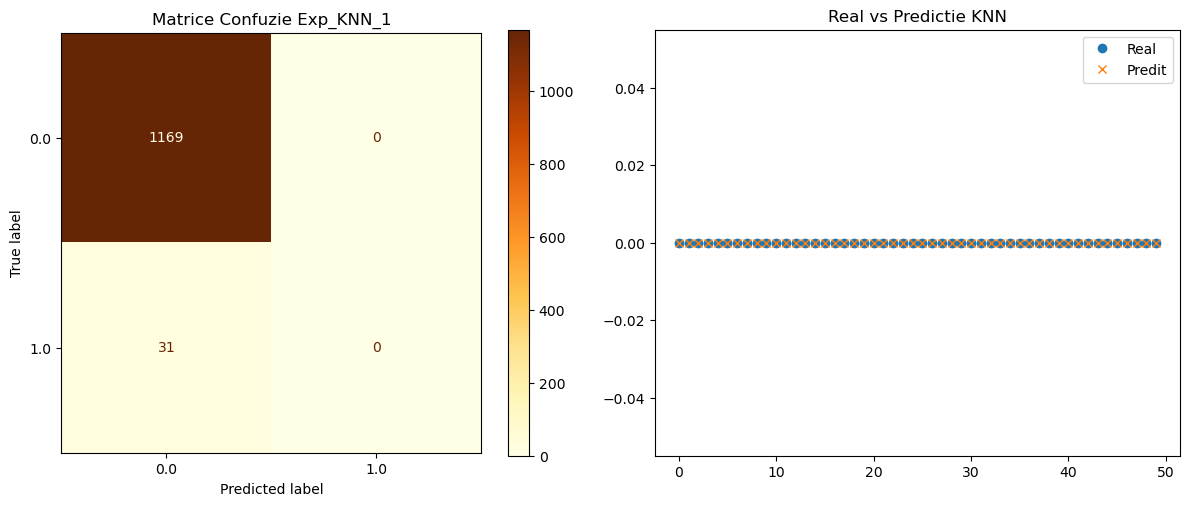

In [2]:
# experiment 1
experiment_knn(k_fold_val=5, n_vecini=5, p_param=2, alg_val='auto', nume_exp="Exp_KNN_1")



--- Exp_KNN_2 ---
Parametri: Vecini=1, p=2 (Minkowski), Algoritm=auto

Clasele: [0. 1.]
Probabilitatile ptr. primele 5 instante test (%):
 [[100.   0.]
 [100.   0.]
 [100.   0.]
 [100.   0.]
 [100.   0.]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 51
Acuratetea de clasificare =  0.96

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1169
         1.0       0.21      0.23      0.22        31

    accuracy                           0.96      1200
   macro avg       0.59      0.60      0.60      1200
weighted avg       0.96      0.96      0.96      1200

Matricea de confuzie:
 [[1142   27]
 [  24    7]]


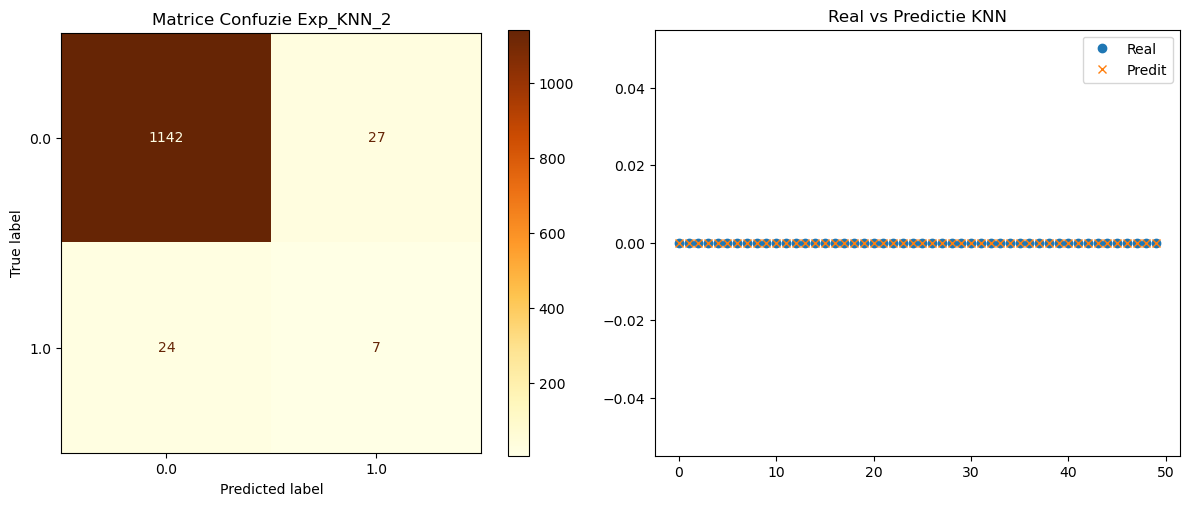

In [3]:
# experiment 2
experiment_knn(k_fold_val=5, n_vecini=1, p_param=2, alg_val='auto', nume_exp="Exp_KNN_2")



--- Exp_KNN_3 ---
Parametri: Vecini=5, p=1 (Minkowski), Algoritm=auto

Clasele: [0. 1.]
Probabilitatile ptr. primele 5 instante test (%):
 [[100.   0.]
 [100.   0.]
 [100.   0.]
 [100.   0.]
 [ 60.  40.]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 32
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1168    1]
 [  31    0]]


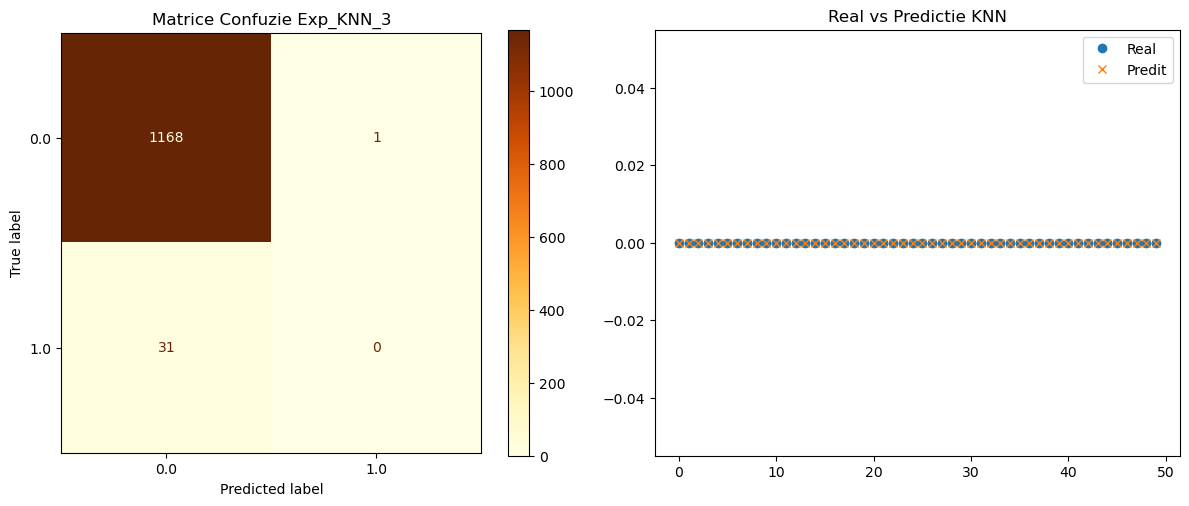

In [4]:
# experiment 3
experiment_knn(k_fold_val=5, n_vecini=5, p_param=1, alg_val='auto', nume_exp="Exp_KNN_3")



--- Exp_KNN_4 ---
Parametri: Vecini=15, p=2 (Minkowski), Algoritm=auto

Clasele: [0. 1.]
Probabilitatile ptr. primele 5 instante test (%):
 [[100.   0.]
 [100.   0.]
 [100.   0.]
 [100.   0.]
 [ 80.  20.]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 31
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


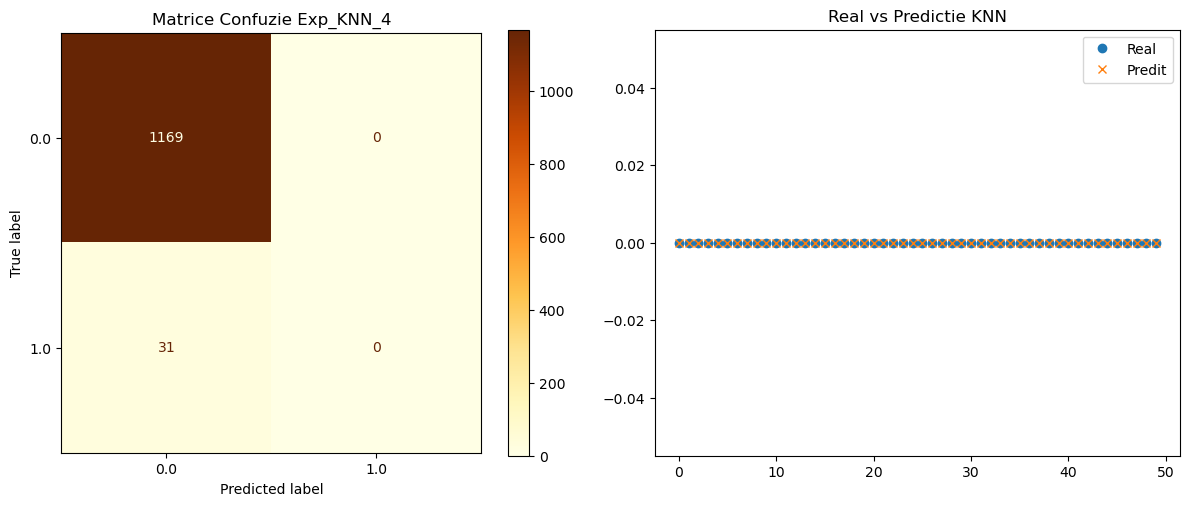

In [5]:
# experiment 4
experiment_knn(k_fold_val=5, n_vecini=15, p_param=2, alg_val='auto', nume_exp="Exp_KNN_4")



--- Exp_KNN_5 ---
Parametri: Vecini=7, p=2 (Minkowski), Algoritm=kd_tree

Clasele: [0. 1.]
Probabilitatile ptr. primele 5 instante test (%):
 [[100.           0.        ]
 [100.           0.        ]
 [100.           0.        ]
 [100.           0.        ]
 [ 71.42857143  28.57142857]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 31
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


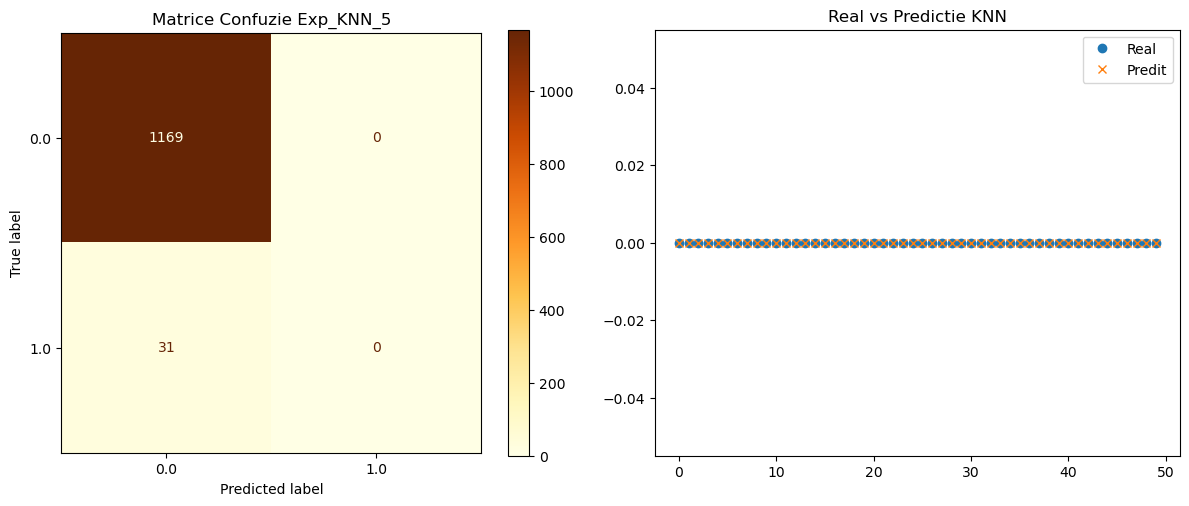

In [6]:
# experiment 5
experiment_knn(k_fold_val=10, n_vecini=7, p_param=2, alg_val='kd_tree', nume_exp="Exp_KNN_5")